# Lecture 6.21: The Forecaster's Toolbox (Part 3)

*DASCI 270 - Time Series Analysis*

*Prepared by Sebastian C. Ibañez, PhD*

*Based on [FPPY Chapter 5](https://otexts.com/fpppy/nbs/05-toolbox.html)*

`And if anyone takes away from the words of the book of this prophecy, God will take away his share in the tree of life and in the holy city, which are described in this book. -Revelation 22:19`

In [1]:
%%capture
!pip install statsforecast

!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_production_formatted.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/gafa_stock.csv' -P ./data/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    RandomWalkWithDrift,
    HistoricAverage,
)

plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

pd.set_option("display.precision", 3)
np.set_printoptions(suppress=True)

## Prediction intervals

**Prediction intervals (PI)** define an interval within which we expect our forecast to lie with a specified probability. This allows us to quantify the uncertainty in our forecasts,

\begin{align*}
    \hat{y}_{T+h} \pm c\hat{\sigma}_h
\end{align*}

where $\hat{y}_{T+h}$ is our point forecast, $\hat{\sigma}_h$ is an estimate of the standard deviation of the $h$-step forecast distribution, and $c$ is a constant that depends on the coverage probability.

For example, assuming that the forecast errors are normally distributed and a 95% prediction interval for the $h$-step forecast,

\begin{align*}
    \hat{y}_{T+h} \pm 1.96\hat{\sigma}_h
\end{align*}

### One-step prediction intervals

When forecasting one step ahead, the standard deviation of the forecast distribution is *almost* the same as the standard deviation of the residuals. In fact, the two standard deviations are identical if there are no parameters to be estimated, as is the case with the naïve method.

For forecasting methods involving parameters to be estimated (e.g., ARIMA, ETS), the standard deviation of the forecast distribution is slightly larger than the residual standard deviation, although this difference is often ignored.

### Multi-step prediction intervals

A common feature of prediction intervals is that they increase in length as the forecast horizon increases. The further ahead we forecast, the more uncertainty is associated with the forecast, and thus the wider the prediction intervals. That is, $\sigma_h$ usually increases with $h$ (although there are some non-linear forecasting methods that do not have this property).

To produce a prediction interval, it is necessary to have an estimate of $\sigma_h$. As already noted, for one-step forecasts ($h = 1$), the residual standard deviation provides a good estimate of the forecast standard deviation $\sigma_1$. For multi-step forecasts, a more complicated method of calculation is required. These calculations assume that the residuals are uncorrelated.

### Prediction intervals for simple methods

For our simple methods, we can mathematically derive the forecast standard deviation *under the assumption of normality and uncorrelated residuals*.

In this case, let $\hat{\sigma}_h$ denote the standard deviation of the $h$-step forecast distribution, and $\hat{\sigma}$ be the residual standard deviation. Then:

\begin{align*}
    \text{Mean Forecasts: } \hat{\sigma}_h &= \hat{\sigma}\sqrt{1 + 1/T} \\
    \text{Naive Forecasts: } \hat{\sigma}_h &= \hat{\sigma}\sqrt{h} \\
    \text{Seasonal Naive Forecasts: } \hat{\sigma}_h &= \hat{\sigma}\sqrt{k+1} \\
    \text{Drift Forecasts: } \hat{\sigma}_h &= \hat{\sigma}\sqrt{h(1 + h/T)}
\end{align*}

where $k$ is the integer part of $(h-1)/m$ and $m$ is the seasonal period.

In [3]:
# Load data
df_gafa = pd.read_csv("data/gafa_stock.csv", parse_dates=["ds"])
df_goog = df_gafa.query("unique_id == 'GOOG_Close' and '2015-01-01' <= ds <= '2016-01-31'")
df_goog = df_goog.reset_index(drop=True)

# Single train-test split
df_train = df_goog.query("ds.dt.year == 2015").copy()
df_test = df_goog.query("ds.dt.year == 2016").copy()

df_train["ds"] = np.arange(len(df_train))
df_test["ds"] = np.arange(len(df_test))

# Forecast
sf = StatsForecast(models=[Naive()], freq=1)

df_f = sf.forecast(h=len(df_test), level=[80, 95], df=df_train)
df_f.head()

,unique_id,ds,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95
0,GOOG_Close,252,758.88,744.540,736.949,773.220,780.811
1,GOOG_Close,253,758.88,738.600,727.865,779.160,789.895
2,GOOG_Close,254,758.88,734.042,720.894,783.718,796.866
3,GOOG_Close,255,758.88,730.200,715.018,787.560,802.742
4,GOOG_Close,256,758.88,726.815,709.840,790.945,807.920


/var/folders/9y/vgkg6w9144v1vtff9_5ft2fw0000gn/T/ipykernel_8284/180268603.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


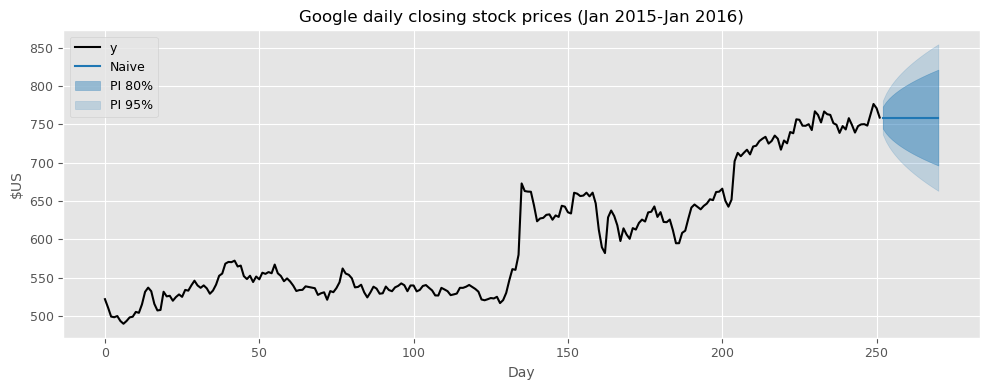

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
df_train.set_index("ds")['y'].plot(ax=ax, legend=False, color='black')
df_f.set_index("ds")['Naive'].plot(ax=ax, color="tab:blue")
ax.fill_between(df_f["ds"], df_f['Naive-lo-80'], df_f['Naive-hi-80'], color='tab:blue', alpha = 0.4)
ax.fill_between(df_f["ds"], df_f['Naive-lo-95'], df_f['Naive-hi-95'], color='tab:blue', alpha = 0.2)
ax.set_title("Google daily closing stock prices (Jan 2015-Jan 2016)")
ax.set_xlabel("Day")
ax.set_ylabel("$US")
plt.legend(["y", "Naive", "PI 80%", "PI 95%"], loc="upper left")
plt.tight_layout()
plt.show()

### Prediction intervals from bootstrapped residuals

If a normal distribution assumption is too unreasonable, one can **bootstrap** the residuals in order to estimate the distribution of the forecast errors. In this case, the only assumption we make is that the forecasts errors are uncorrelated.

To simulate a forecast with errors, we can compute:

\begin{align*}
    y_{T+1} &= \hat{y}_{T+1|T} + e_{T+1}
\end{align*}

where $e_{T+1}$ is sampled from the collection of residuals. We can then simulate the next observation as:

\begin{align*}
    y_{T+2} &= \hat{y}_{T+2|T+1} + e_{T+2}
\end{align*}

where $e_{T+2}$ is once again sampled from the collection of residuals. We repeat the process until we reach $T+h$, at which point we would have generated a single realization of our test set.

Performing this process many times will give us an empirical estimate of the full forecast distribution. We can then compute prediction intervals by calculating percentiles at each forecast horizon. The result is called a **bootsrapped prediction interval**.

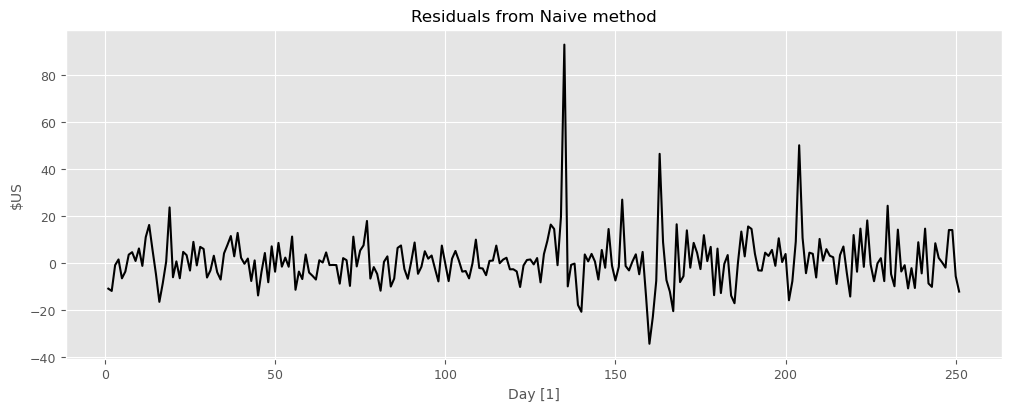

In [10]:
# Forecast
sf = StatsForecast(models=[Naive()], freq=1)
df_f = sf.forecast(h=len(df_test), df=df_train, fitted=True)

# Get residuals
df_fitted = sf.forecast_fitted_values() # get fitted values
df_fitted = df_fitted.rename({"Naive": "fitted"}, axis=1)
df_fitted["resid"] = df_fitted["y"] - df_fitted["fitted"]
df_fitted = df_fitted.dropna()

fig, ax = plt.subplots()
df_fitted.plot(ax=ax, x='ds', y='resid', color='black', legend=False)
ax.set_title("Residuals from Naive method")
ax.set_xlabel("Day [1]")
ax.set_ylabel("$US")
plt.autoscale()
plt.show()

/var/folders/9y/vgkg6w9144v1vtff9_5ft2fw0000gn/T/ipykernel_8284/2495486078.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


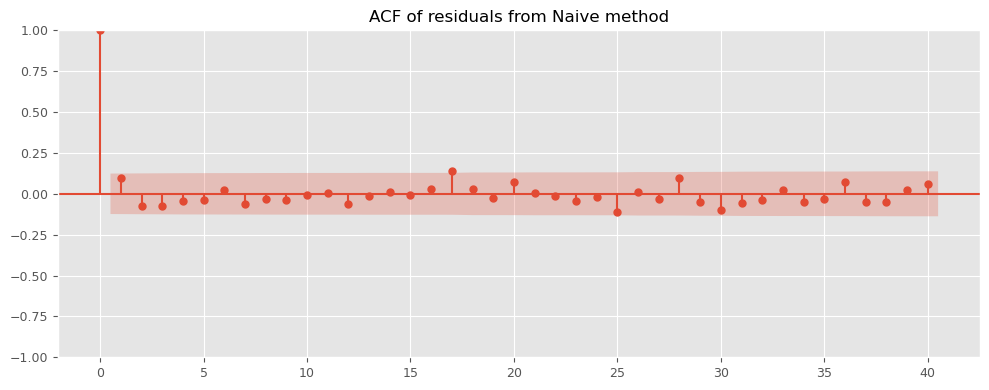

In [11]:
#plot acf
fig, ax = plt.subplots()
plot_acf(df_fitted["resid"], lags=40, ax=ax)
ax.set_title("ACF of residuals from Naive method")
plt.tight_layout()
plt.show()

In [12]:
# Generate bootstrapped paths for naive
n_sim = 1000
h = 40
forecasts = []
for i in range(n_sim):
    y_t = df_train.iloc[-1]['y']
    sim = []
    for j in range(h):
        pred = y_t + np.random.choice(df_fitted['resid'].values, size=1, replace=True)[0]
        sim.append(pred)
        y_t = pred
    sim = np.asarray(sim)
    forecasts.append(sim)
forecasts = np.asarray(forecasts)

df_f = pd.DataFrame(forecasts.T)
df_f.index = range(df_train.iloc[-1]['ds'] + 1, df_train.iloc[-1]['ds'] + 1 + h)
df_f

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
252,754.510,770.148,770.198,766.473,760.440,751.210,758.612,755.220,755.280,751.277,...,777.070,785.930,762.120,775.430,769.460,751.277,763.544,757.338,759.134,764.480
253,763.140,762.478,773.599,769.377,765.500,739.867,757.042,764.000,741.450,769.467,...,781.635,777.198,760.040,770.690,765.651,748.167,760.434,769.298,769.914,766.710
254,756.560,774.378,766.619,768.277,763.810,736.307,758.151,778.560,739.370,762.807,...,785.605,768.328,759.215,770.680,755.531,750.277,764.134,768.758,780.993,762.420
255,746.580,775.134,762.959,759.617,764.969,726.187,761.021,781.800,744.733,773.387,...,780.055,769.378,759.775,760.700,747.741,747.077,768.928,775.678,784.133,745.340
256,764.541,771.233,754.089,771.517,764.004,727.237,769.802,777.430,745.393,769.827,...,766.225,762.585,747.655,763.210,745.131,761.777,769.182,781.308,807.862,738.866
257,766.451,777.423,755.317,767.509,775.322,728.466,775.848,780.490,759.953,756.177,...,767.486,758.936,756.267,779.760,745.971,753.045,773.152,784.738,800.072,785.426
258,756.611,778.003,752.707,753.859,776.882,724.458,778.908,774.483,783.682,749.197,...,770.887,761.223,757.397,789.760,760.061,751.355,774.067,798.848,789.192,780.296
259,755.756,767.833,753.017,753.849,776.262,725.958,782.518,777.363,775.537,749.507,...,772.836,760.049,762.927,803.720,758.841,775.084,768.517,798.228,787.112,783.356
260,751.855,771.073,744.147,750.199,775.042,719.298,774.848,767.453,771.977,769.137,...,766.044,760.805,765.217,802.620,752.243,766.939,769.357,812.778,776.522,781.276
261,750.715,770.247,742.747,749.869,794.672,720.038,774.518,768.403,776.437,787.327,...,776.824,761.115,770.817,796.484,761.693,752.869,776.876,817.572,781.292,773.672


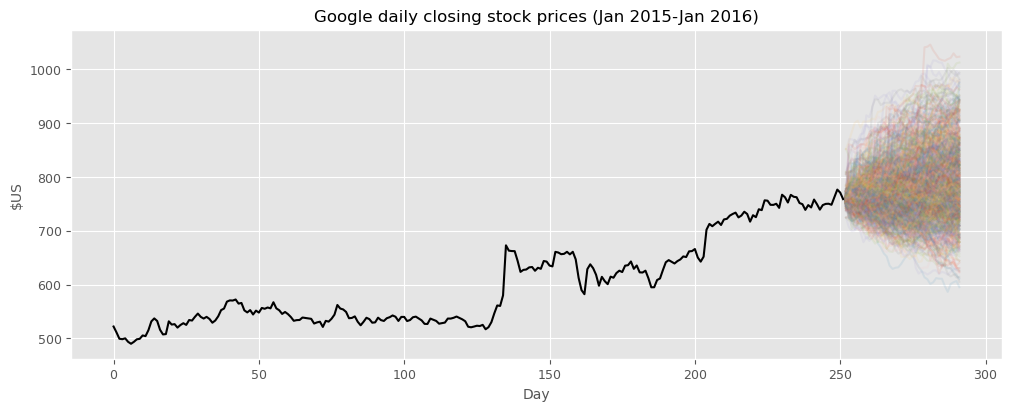

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
df_train.set_index("ds")['y'].plot(ax=ax, color='black', legend=False)
df_f.plot(ax=ax, legend=False, alpha=0.1)
ax.set_title("Google daily closing stock prices (Jan 2015-Jan 2016)")
ax.set_xlabel("Day")
ax.set_ylabel("$US")
plt.show()

Note that the plot above *does not* show a prediction interval. Rather, it is an empirical estimate of the full distribution.

To calculate a prediction interval, we can calculate quantiles/percentiles on the simulated forecasts.

In [14]:
alpha = 0.05

df_naive = pd.DataFrame()
df_naive['Naive'] = np.repeat(df_train.iloc[-1]['y'], h)
df_naive['Lo'] = df_f.T.quantile(q=alpha/2).to_numpy()       # 0.025
df_naive['Hi'] = df_f.T.quantile(q=(1 - alpha/2)).to_numpy() # 0.975
df_naive.index = df_f.index
df_naive.head()

,Naive,Lo,Hi
252,758.88,742.391,778.510
253,758.88,736.374,798.453
254,758.88,728.813,804.107
255,758.88,726.187,813.511
256,758.88,725.288,819.425


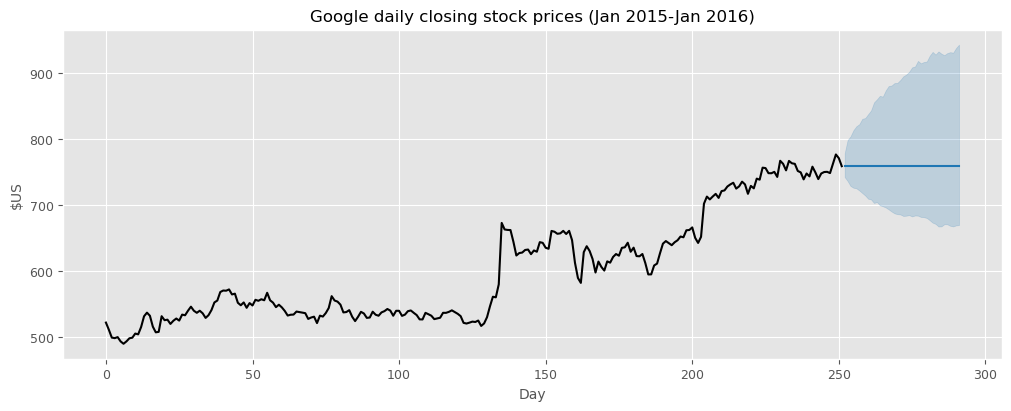

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
df_train.set_index("ds")['y'].plot(ax=ax, color='black', legend=False)
df_naive['Naive'].plot(ax=ax, color='tab:blue', legend=False)
ax.fill_between(df_naive.index, df_naive['Lo'], df_naive['Hi'], color='tab:blue', alpha=0.2)
ax.set_title("Google daily closing stock prices (Jan 2015-Jan 2016)")
ax.set_xlabel("Day")
ax.set_ylabel("$US")
plt.show()

### Conformal prediction for distribution-free prediction intervals

While traditional prediction intervals rely on assumptions about the forecast distribution—typically assuming normality—**conformal prediction** offers a flexible, model-agnostic alternative that does not require strong distributional assumptions.

Instead of estimating prediction intervals based on a predefined probabilistic model, conformal prediction constructs intervals using past forecast errors, ensuring that the empirical coverage closely matches the desired confidence level.

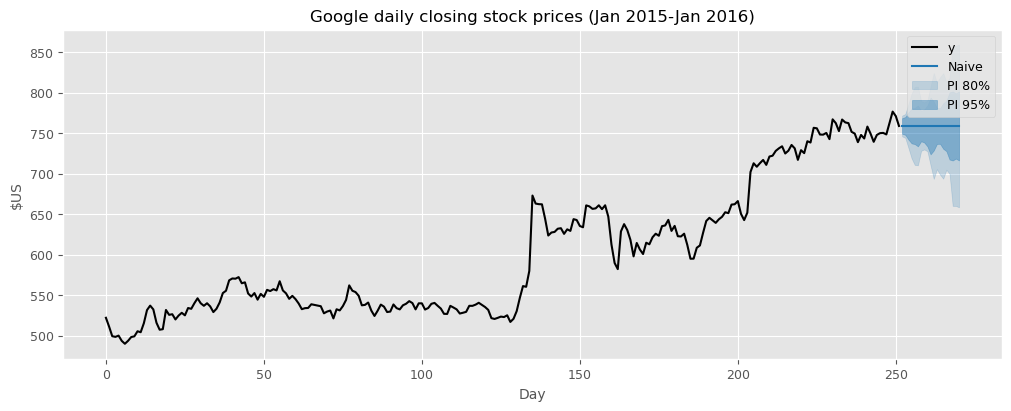

In [17]:
from statsforecast.utils import ConformalIntervals

intervals = ConformalIntervals(h=len(df_test), n_windows=100)

models = [
    Naive(prediction_intervals=intervals),
]
level = [80, 95]

sf = StatsForecast(models=models, freq=1)
df_f = sf.forecast(df=df_train, h=len(df_test), level=level)

fig, ax = plt.subplots(figsize=(10, 4))
df_train.set_index("ds")['y'].plot(ax=ax, legend=False, color='black')
df_f.set_index("ds")['Naive'].plot(ax=ax, color="tab:blue")
ax.fill_between(df_f["ds"], df_f['Naive-lo-95'], df_f['Naive-hi-95'], color='tab:blue', alpha = 0.2)
ax.fill_between(df_f["ds"], df_f['Naive-lo-80'], df_f['Naive-hi-80'], color='tab:blue', alpha = 0.4)
ax.set_title("Google daily closing stock prices (Jan 2015-Jan 2016)")
ax.set_xlabel("Day")
ax.set_ylabel("$US")
plt.legend(["y", "Naive", "PI 80%", "PI 95%"])
plt.show()